# Analysis of &alpha;5&beta;1 MD simulations

Date: 11-14-2023

Simulations were conducted using the OpenMM7.7 package employing AMBER ff19SB force fields.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import sem
import pandas as pd
import glob

## Plot time-evolved RMSD for each replicate
- Corresponds to Figure S11

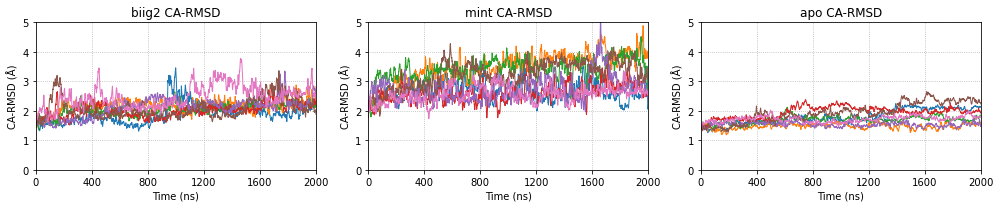

In [2]:
plt.figure(figsize=(14,3))

system_list = ["biig2", "mint", "apo"]
path = "rmsd-rmsf-CA/"
frames=20000
ave_rmsd = []

for antibody, i in zip(system_list, range(len(system_list))):
    plt.subplot(1,3, i+1)
    plt.title(f"{antibody} CA-RMSD")
    plt.xlabel("Time (ns)")
    plt.xticks(np.arange(0,28000,4000), np.arange(0,2800,400))
    plt.ylabel("CA-RMSD (Å)")
    plt.ylim([0, 5])
    plt.xlim([0,20000])
    plt.grid(linestyle=":")

    for dat_file in sorted(glob.glob(f"{path}/a5b1_{antibody}_clone*-rmsd-CA.dat")):
        rmsd = np.loadtxt(dat_file)[:,1]
        smooth_rmsd = savgol_filter(rmsd, 101, 3)
        plt.plot(smooth_rmsd, linewidth=1)
            
plt.tight_layout()
#plt.savefig("ab51_CA-RMSD.svg")

## Plot average per-residue RMSF
- Corresponds to Figure S11

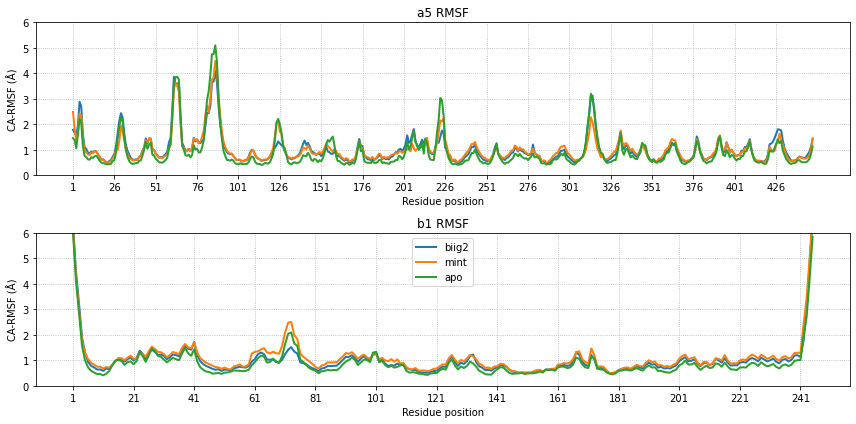

In [3]:
plt.figure(figsize=(12,6))

system_list = ["biig2", "mint", "apo"]
path = "rmsd-rmsf-CA/"

for antibody in system_list:
    
    replicates_rmsf = []
    for dat_file in sorted(glob.glob(f"{path}/a5b1_{antibody}_clone*-rmsf-CA.dat")):
        rmsf = np.loadtxt(dat_file)[:,1]
        replicates_rmsf.append(rmsf)
           
    
    mean_rmsf = np.mean(replicates_rmsf, axis=0)
    sem_rmsf = sem(replicates_rmsf, axis=0)
    std_rmsf = np.std(replicates_rmsf, axis=0)
    
    plt.subplot(2,1,1)
    plt.plot(mean_rmsf[0:448], linewidth=2, label=f"{antibody}")
    plt.title(f"a5 RMSF")
    plt.xlabel("Residue position")
    plt.xticks(np.arange(0,450,25), np.arange(1,450,25))
    plt.ylabel("CA-RMSF (Å)")
    plt.ylim([0, 6])
    plt.grid(linestyle=":")
    
    
    plt.subplot(2,1,2)
    plt.plot(mean_rmsf[448:693], linewidth=2, label=f"{antibody}")
    plt.title(f"b1 RMSF")
    plt.xlabel("Residue position")
    plt.xticks(np.arange(0,250,20), np.arange(1,251,20))
    plt.ylabel("CA-RMSF (Å)")
    plt.ylim([0, 6])
    plt.grid(linestyle=":")
    
plt.legend()
plt.tight_layout()
#plt.savefig("ab51_CA-RMSF.svg")

## Plot angle and distance of met-aromatic interaction in &alpha;5&beta;1:BIIG2
- Corresponds to Figure S10

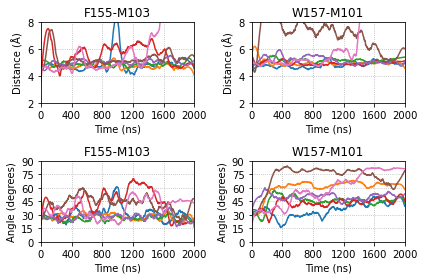

In [4]:
pairs = ["F155-M103", "W157-M101"]

plt.figure()
for resid_pair, plt_idx in zip(pairs, range(len(pairs))):
    plt.subplot(2,2,plt_idx+1)
    for clone in sorted(glob.glob(f"met-aromatic_interaction/a5b1_biig2_clone*-{resid_pair}-dist.npy")):
        a = np.load(clone)[0:20000:20]*10
        smooth_data = savgol_filter(a, 101, 3)
        plt.plot(smooth_data)
    plt.title(resid_pair)
    plt.xticks(np.arange(0,len(smooth_data)+200,200), np.arange(0,2400,400))
    plt.ylim([2,8])
    plt.xlim([0,1000])
    plt.xlabel("Time (ns)")
    plt.ylabel("Distance (Å)")
    plt.grid(linestyle=":")

for resid_pair, plt_idx in zip(pairs, range(len(pairs))):
    plt.subplot(2,2,plt_idx+3)
    for clone in sorted(glob.glob(f"met-aromatic_interaction/a5b1_biig2_clone*-{resid_pair}-angle.npy")):
        a = np.load(clone)[0:20000:20]
        smooth_data = savgol_filter(a, 101, 3)
        plt.plot(smooth_data)
    plt.title(resid_pair)
    plt.xticks(np.arange(0,len(smooth_data)+200,200), np.arange(0,2400,400))
    plt.xlim([0,1000])
    plt.ylim([0,90])
    plt.yticks([0,15,30,45,60,75,90])
    plt.xlabel("Time (ns)")
    plt.ylabel("Angle (degrees)")
    plt.grid(linestyle=":")
    
plt.tight_layout()
plt.show()
#plt.savefig("aromatic-met-interaction-time.svg")

## Print hydrogen bond probabilities of &alpha;5&beta;1:Fab interface
- Corresponding to Figures 4D, 5F

In [5]:
biig2_df = pd.read_csv("hbond_prob/a5b1_biig2_hbond_freq.csv")

traj_mask = biig2_df.columns.str.contains('.*_freq')

for index, row in biig2_df.iterrows():
    freq_ave = np.mean(row[traj_mask])
    freq_sem = sem(row[traj_mask])
    freq_std = np.std(row[traj_mask])

    if freq_ave < 0.10:
        continue
    
    label = f"{row['a5b1_resn']}{row['a5b1_resid']}({row['subunit']}) - {row['fab_resid']}{row['fab_resn']}({row['subunit2']})"
    
    print(f"{label} {freq_ave*100:.0f}+/-{freq_sem*100:.0f}")
    

E81(a) - K27(L) 33+/-8
E124(a) - K92(L) 69+/-16
E124(a) - Y94(L) 56+/-16
K125(a) - H91(L) 40+/-10
K125(a) - D98(H) 26+/-10
K125(a) - R99(H) 22+/-11
E126(a) - R99(H) 12+/-12
E126(a) - T100(H) 58+/-14
E126(a) - N33(H) 50+/-13
D154(a) - T104(H) 88+/-6
D154(a) - K31(L) 51+/-13
D154(a) - Y32(L) 68+/-8
S156(a) - G102(H) 77+/-9
Y205(a) - R28(L) 35+/-3
Y208(a) - S30(L) 56+/-7
S189(b) - G54(H) 93+/-4
E190(b) - R71(H) 88+/-4


In [6]:
mint_df = pd.read_csv("hbond_prob/a5b1_mint_hbond_freq.csv")

traj_mask = mint_df.columns.str.contains('.*_freq')

for index, row in mint_df.iterrows():
    freq_ave = np.mean(row[traj_mask])
    freq_sem = sem(row[traj_mask])
    freq_std = np.std(row[traj_mask])

    if freq_ave < 0.10:
        continue
    
    label = f"{row['a5b1_resn']}{row['a5b1_resid']}({row['subunit']}) - {row['fab_resid']}{row['fab_resn']}({row['subunit2']})"
    
    print(f"{label} {freq_ave*100:.0f}+/-{freq_sem*100:.0f}")
    

E81(a) - R32(H) 14+/-4
R144(a) - P55(H) 36+/-14
D154(a) - Y50(L) 17+/-4
A201(a) - N56(H) 40+/-16
E202(a) - R105(H) 94+/-5
E202(a) - K52(H) 71+/-8
S203(a) - R105(H) 47+/-7
Y204(a) - N56(H) 58+/-12
Y205(a) - W33(H) 94+/-6
Y205(a) - L101(H) 98+/-2
E207(a) - R32(H) 43+/-9
Y208(a) - Y109(H) 28+/-7
Y208(a) - R32(H) 81+/-9
L212(a) - G103(H) 80+/-9
L212(a) - R105(H) 81+/-10
Q214(a) - S96(L) 68+/-10
Q214(a) - T32(L) 57+/-12
R220(a) - D54(L) 42+/-5
Y205(a) - W33(H) 100+/-0
